# Product Category and Region Level Forecasting

In [ ]:
# ==========================================
# Import Libraries
# ==========================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.statespace.sarimax import SARIMAX

import warnings
warnings.filterwarnings("ignore")

plt.style.use("ggplot")
plt.rcParams["figure.figsize"] = (14,6)

# Load Dataset

In [3]:
# ==========================================
# Load Dataset
# ==========================================

df = pd.read_csv(r"C:\Users\amans\Downloads\train.csv.zip")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


# Order Date Function

In [5]:
df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)

In [6]:
print(df.shape)

(9800, 18)


# View Dataset

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9800 non-null   int64         
 1   Order ID       9800 non-null   object        
 2   Order Date     9800 non-null   datetime64[ns]
 3   Ship Date      9800 non-null   object        
 4   Ship Mode      9800 non-null   object        
 5   Customer ID    9800 non-null   object        
 6   Customer Name  9800 non-null   object        
 7   Segment        9800 non-null   object        
 8   Country        9800 non-null   object        
 9   City           9800 non-null   object        
 10  State          9800 non-null   object        
 11  Postal Code    9789 non-null   float64       
 12  Region         9800 non-null   object        
 13  Product ID     9800 non-null   object        
 14  Category       9800 non-null   object        
 15  Sub-Category   9800 n

In [8]:
print(df["Category"].unique())

['Furniture' 'Office Supplies' 'Technology']


In [9]:
print(df["Region"].unique())

['South' 'West' 'Central' 'East']


# Create Monthly Sales Function

In [11]:
def monthly_sales(data):

    monthly = (
        data
        .groupby(pd.Grouper(
            key="Order Date",
            freq="M"
        ))["Sales"]
        .sum()
        .reset_index()
    )

    return monthly

# SARIMA Forecast prediction confidence

In [12]:
def sarima_forecast(data,
                    periods=3):

    ts = monthly_sales(data)

    ts = ts.set_index("Order Date")

    model = SARIMAX(
        ts["Sales"],
        order=(1,1,1),
        seasonal_order=(1,1,1,12),
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    result = model.fit(disp=False)

    forecast = result.get_forecast(
        steps=periods
    )

    prediction = forecast.predicted_mean

    confidence = forecast.conf_int()

    return prediction, confidence

In [13]:
prediction, confidence = sarima_forecast(df)

prediction

2019-01-31    46782.479176
2019-02-28    40285.470532
2019-03-31    72234.203230
Freq: ME, Name: predicted_mean, dtype: float64

# Sample Sales Forecast

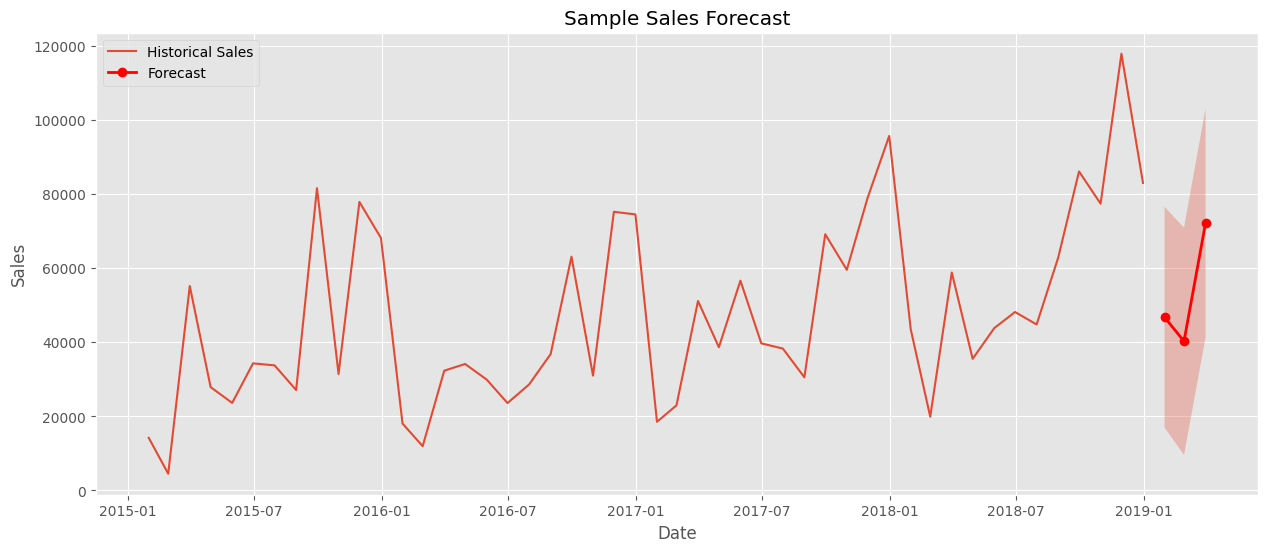

In [14]:
monthly = monthly_sales(df)

monthly = monthly.set_index("Order Date")

prediction, confidence = sarima_forecast(df)

plt.figure(figsize=(15,6))

plt.plot(
    monthly.index,
    monthly["Sales"],
    label="Historical Sales"
)

plt.plot(
    prediction.index,
    prediction,
    color="red",
    marker="o",
    linewidth=2,
    label="Forecast"
)

plt.fill_between(
    confidence.index,
    confidence.iloc[:,0],
    confidence.iloc[:,1],
    alpha=0.3
)

plt.title("Sample Sales Forecast")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.legend()

plt.grid(True)

plt.show()

# Forecast table

In [15]:
forecast_df = pd.DataFrame({

    "Forecast Sales":prediction,

    "Lower CI":confidence.iloc[:,0],

    "Upper CI":confidence.iloc[:,1]

})

forecast_df

,Forecast Sales,Lower CI,Upper CI
2019-01-31,46782.479176,16992.673562,76572.284790
2019-02-28,40285.470532,9596.040125,70974.900940
2019-03-31,72234.203230,41318.855902,103149.550558


In [16]:
forecast_df.to_csv(
    "overall_forecast.csv"
)

In [17]:
# ======================================
# Filter Data by Category
# ======================================

furniture_df = df[df["Category"] == "Furniture"]

technology_df = df[df["Category"] == "Technology"]

office_df = df[df["Category"] == "Office Supplies"]

# Furniture Shape

In [18]:
print("Furniture :", furniture_df.shape)

print("Technology :", technology_df.shape)

print("Office Supplies :", office_df.shape)

Furniture : (2078, 18)
Technology : (1813, 18)
Office Supplies : (5909, 18)


# Furniture Prediction

In [19]:
furniture_prediction, furniture_ci = sarima_forecast(
    furniture_df,
    periods=3
)

furniture_prediction

2019-01-31    10526.766773
2019-02-28     9921.588935
2019-03-31    16576.869442
Freq: ME, Name: predicted_mean, dtype: float64

# Technology Prediction

In [20]:
technology_prediction, technology_ci = sarima_forecast(
    technology_df,
    periods=3
)

technology_prediction

2019-01-31    20100.376895
2019-02-28    18198.549188
2019-03-31    32443.115061
Freq: ME, Name: predicted_mean, dtype: float64

# Office Prediction

In [21]:
office_prediction, office_ci = sarima_forecast(
    office_df,
    periods=3
)

office_prediction

2019-01-31    17978.323410
2019-02-28    15467.386741
2019-03-31    23346.412014
Freq: ME, Name: predicted_mean, dtype: float64

# Furniture Forecast

In [22]:
furniture_forecast = pd.DataFrame({

    "Forecast Sales": furniture_prediction,

    "Lower CI": furniture_ci.iloc[:,0],

    "Upper CI": furniture_ci.iloc[:,1]

})

furniture_forecast

,Forecast Sales,Lower CI,Upper CI
2019-01-31,10526.766773,133.368544,20920.165002
2019-02-28,9921.588935,-485.887712,20329.065582
2019-03-31,16576.869442,5889.801391,27263.937493


# Technology Prediction

In [23]:
technology_forecast = pd.DataFrame({

    "Forecast Sales": technology_prediction,

    "Lower CI": technology_ci.iloc[:,0],

    "Upper CI": technology_ci.iloc[:,1]

})

technology_forecast

,Forecast Sales,Lower CI,Upper CI
2019-01-31,20100.376895,-78.202737,40278.956527
2019-02-28,18198.549188,-1973.768993,38370.867370
2019-03-31,32443.115061,12211.544245,52674.685876


# Office Forecast

In [24]:
office_forecast = pd.DataFrame({

    "Forecast Sales": office_prediction,

    "Lower CI": office_ci.iloc[:,0],

    "Upper CI": office_ci.iloc[:,1]

})

office_forecast

,Forecast Sales,Lower CI,Upper CI
2019-01-31,17978.323410,2297.087165,33659.559656
2019-02-28,15467.386741,-867.985155,31802.758636
2019-03-31,23346.412014,6905.335961,39787.488068


# Furniture Sales Forecast

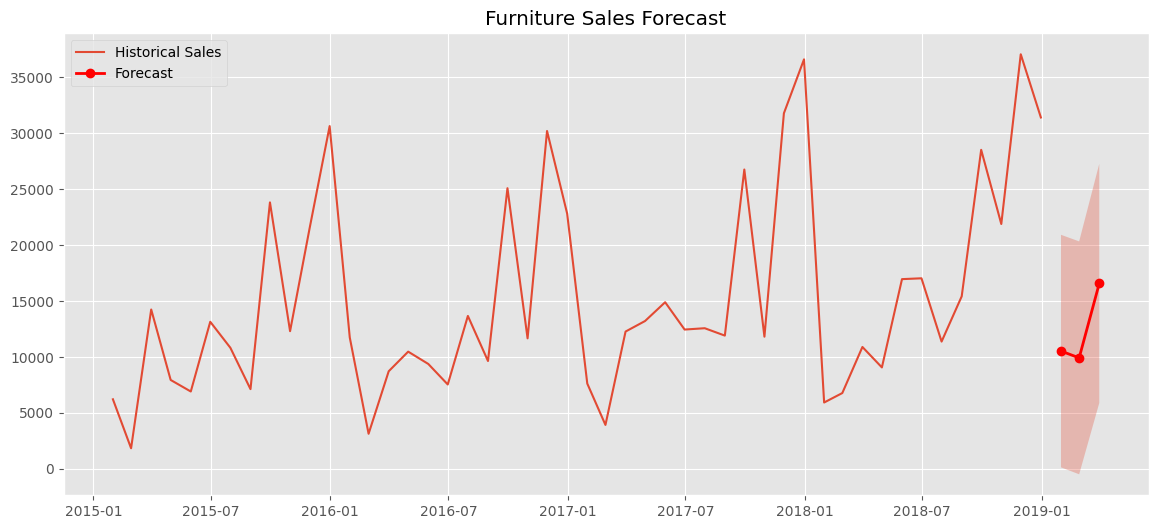

In [25]:
monthly_furniture = monthly_sales(furniture_df)

monthly_furniture = monthly_furniture.set_index("Order Date")

plt.figure(figsize=(14,6))

plt.plot(
    monthly_furniture.index,
    monthly_furniture["Sales"],
    label="Historical Sales"
)

plt.plot(
    furniture_prediction.index,
    furniture_prediction,
    marker="o",
    linewidth=2,
    color="red",
    label="Forecast"
)

plt.fill_between(
    furniture_ci.index,
    furniture_ci.iloc[:,0],
    furniture_ci.iloc[:,1],
    alpha=0.30
)

plt.title("Furniture Sales Forecast")

plt.legend()

plt.grid(True)

plt.show()

# Technology Sales Forecast

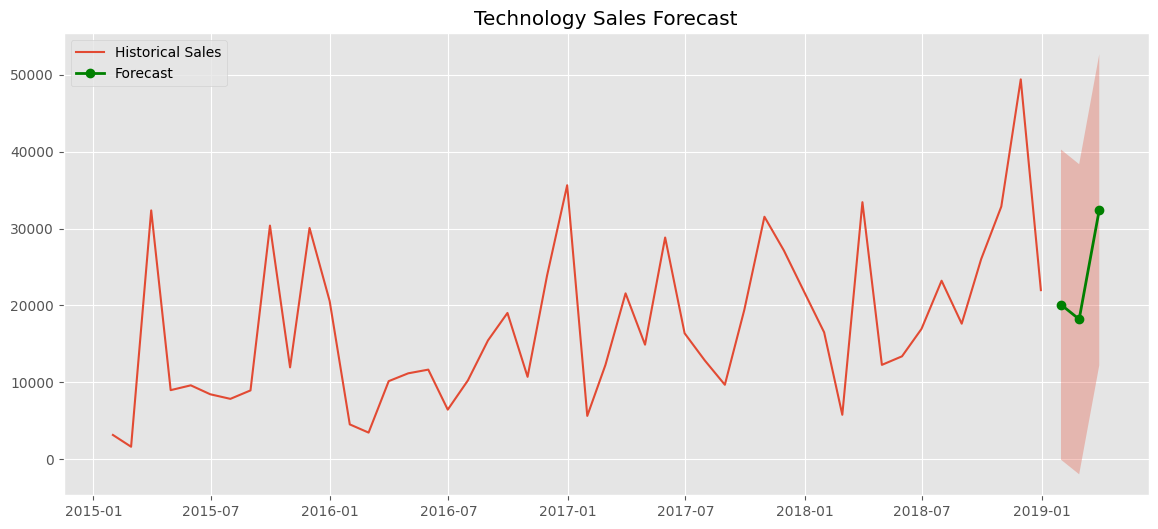

In [26]:
monthly_technology = monthly_sales(technology_df)

monthly_technology = monthly_technology.set_index("Order Date")

plt.figure(figsize=(14,6))

plt.plot(
    monthly_technology.index,
    monthly_technology["Sales"],
    label="Historical Sales"
)

plt.plot(
    technology_prediction.index,
    technology_prediction,
    marker="o",
    linewidth=2,
    color="green",
    label="Forecast"
)

plt.fill_between(
    technology_ci.index,
    technology_ci.iloc[:,0],
    technology_ci.iloc[:,1],
    alpha=0.30
)

plt.title("Technology Sales Forecast")

plt.legend()

plt.grid(True)

plt.show()

# Office Supplies Sales Forecast

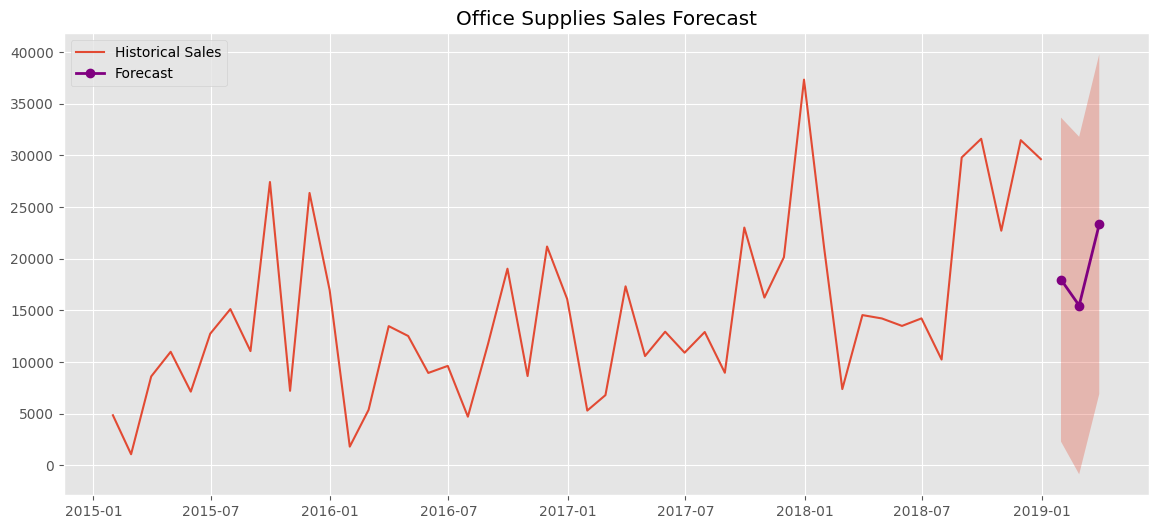

In [27]:
monthly_office = monthly_sales(office_df)

monthly_office = monthly_office.set_index("Order Date")

plt.figure(figsize=(14,6))

plt.plot(
    monthly_office.index,
    monthly_office["Sales"],
    label="Historical Sales"
)

plt.plot(
    office_prediction.index,
    office_prediction,
    marker="o",
    linewidth=2,
    color="purple",
    label="Forecast"
)

plt.fill_between(
    office_ci.index,
    office_ci.iloc[:,0],
    office_ci.iloc[:,1],
    alpha=0.30
)

plt.title("Office Supplies Sales Forecast")

plt.legend()

plt.grid(True)

plt.show()

# Comparison Table

In [28]:
comparison = pd.DataFrame({

    "Furniture": furniture_prediction,

    "Technology": technology_prediction,

    "Office Supplies": office_prediction

})

comparison

,Furniture,Technology,Office Supplies
2019-01-31,10526.766773,20100.376895,17978.323410
2019-02-28,9921.588935,18198.549188,15467.386741
2019-03-31,16576.869442,32443.115061,23346.412014


# Category Wise 3 Month Sales Forecast

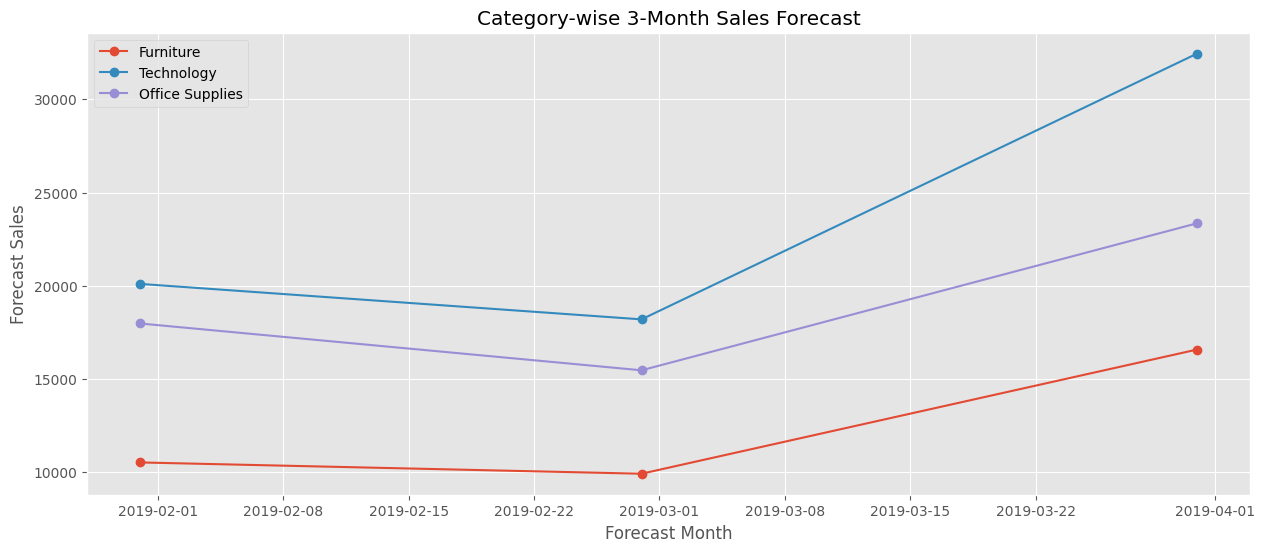

In [29]:
plt.figure(figsize=(15,6))

plt.plot(
    comparison.index,
    comparison["Furniture"],
    marker="o",
    label="Furniture"
)

plt.plot(
    comparison.index,
    comparison["Technology"],
    marker="o",
    label="Technology"
)

plt.plot(
    comparison.index,
    comparison["Office Supplies"],
    marker="o",
    label="Office Supplies"
)

plt.title("Category-wise 3-Month Sales Forecast")

plt.xlabel("Forecast Month")

plt.ylabel("Forecast Sales")

plt.legend()

plt.grid(True)

plt.show()

In [30]:
furniture_forecast.to_csv(
    "furniture_forecast.csv"
)

technology_forecast.to_csv(
    "technology_forecast.csv"
)

office_forecast.to_csv(
    "office_supplies_forecast.csv"
)

comparison.to_csv(
    "category_forecast_comparison.csv"
)

In [31]:
# ======================================
# Filter Data by Region
# ======================================

west_df = df[df["Region"] == "West"]

east_df = df[df["Region"] == "East"]

In [32]:
print("West Region Shape :", west_df.shape)

print("East Region Shape :", east_df.shape)

West Region Shape : (3140, 18)
East Region Shape : (2785, 18)


# West Prediction

In [33]:
west_prediction, west_ci = sarima_forecast(
    west_df,
    periods=3
)

west_prediction

2019-01-31    15478.135160
2019-02-28    13405.168156
2019-03-31    28366.091033
Freq: ME, Name: predicted_mean, dtype: float64

# East Prediction

In [34]:
east_prediction, east_ci = sarima_forecast(
    east_df,
    periods=3
)

east_prediction

2019-01-31    11878.473034
2019-02-28    13477.979195
2019-03-31    19848.300081
Freq: ME, Name: predicted_mean, dtype: float64

# West Forecast

In [35]:
west_forecast = pd.DataFrame({

    "Forecast Sales": west_prediction,

    "Lower CI": west_ci.iloc[:,0],

    "Upper CI": west_ci.iloc[:,1]

})

west_forecast

,Forecast Sales,Lower CI,Upper CI
2019-01-31,15478.135160,7531.102094,23425.168227
2019-02-28,13405.168156,5434.623578,21375.712734
2019-03-31,28366.091033,20368.606878,36363.575189


# East Forecast

In [36]:
east_forecast = pd.DataFrame({

    "Forecast Sales": east_prediction,

    "Lower CI": east_ci.iloc[:,0],

    "Upper CI": east_ci.iloc[:,1]

})

east_forecast

,Forecast Sales,Lower CI,Upper CI
2019-01-31,11878.473034,-6227.939182,29984.885251
2019-02-28,13477.979195,-6884.634142,33840.592532
2019-03-31,19848.300081,-1359.410082,41056.010244


# West Region Sales Forecast

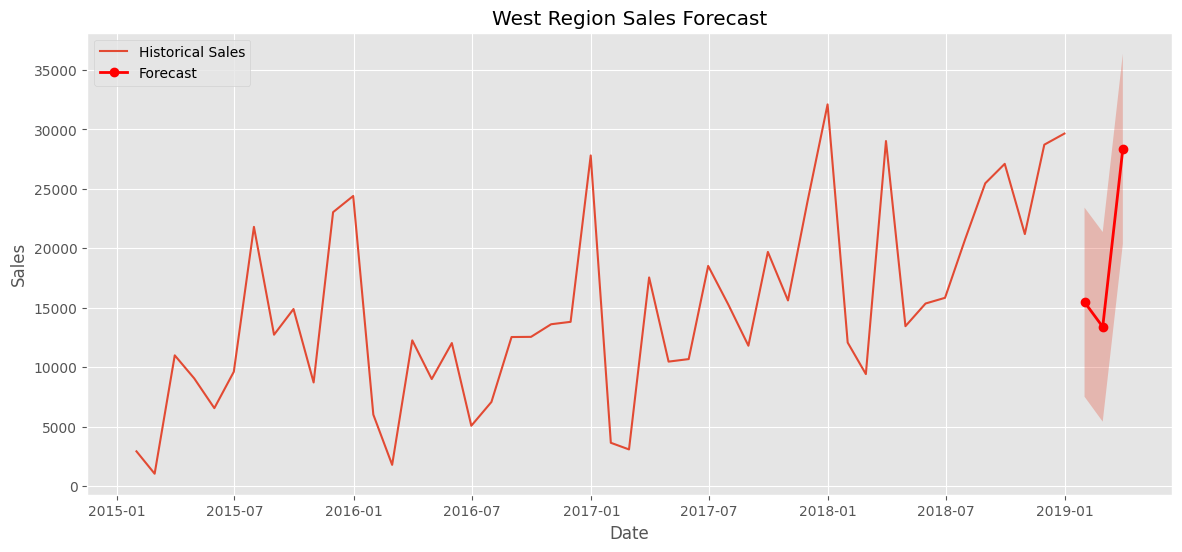

In [37]:
monthly_west = monthly_sales(west_df)

monthly_west = monthly_west.set_index("Order Date")

plt.figure(figsize=(14,6))

plt.plot(
    monthly_west.index,
    monthly_west["Sales"],
    label="Historical Sales"
)

plt.plot(
    west_prediction.index,
    west_prediction,
    marker="o",
    linewidth=2,
    color="red",
    label="Forecast"
)

plt.fill_between(
    west_ci.index,
    west_ci.iloc[:,0],
    west_ci.iloc[:,1],
    alpha=0.30
)

plt.title("West Region Sales Forecast")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.legend()

plt.grid(True)

plt.show()

# East Region Sales Forecast

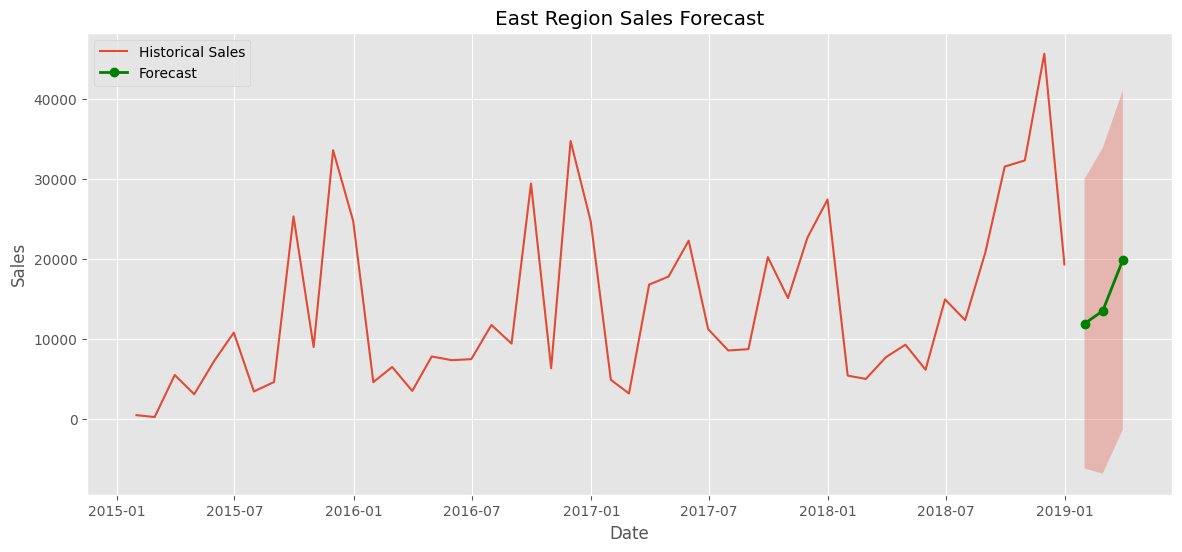

In [38]:
monthly_east = monthly_sales(east_df)

monthly_east = monthly_east.set_index("Order Date")

plt.figure(figsize=(14,6))

plt.plot(
    monthly_east.index,
    monthly_east["Sales"],
    label="Historical Sales"
)

plt.plot(
    east_prediction.index,
    east_prediction,
    marker="o",
    linewidth=2,
    color="green",
    label="Forecast"
)

plt.fill_between(
    east_ci.index,
    east_ci.iloc[:,0],
    east_ci.iloc[:,1],
    alpha=0.30
)

plt.title("East Region Sales Forecast")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.legend()

plt.grid(True)

plt.show()

# Region Comparison

In [39]:
region_comparison = pd.DataFrame({

    "West": west_prediction,

    "East": east_prediction

})

region_comparison

,West,East
2019-01-31,15478.135160,11878.473034
2019-02-28,13405.168156,13477.979195
2019-03-31,28366.091033,19848.300081


# West vs East Region Forecast

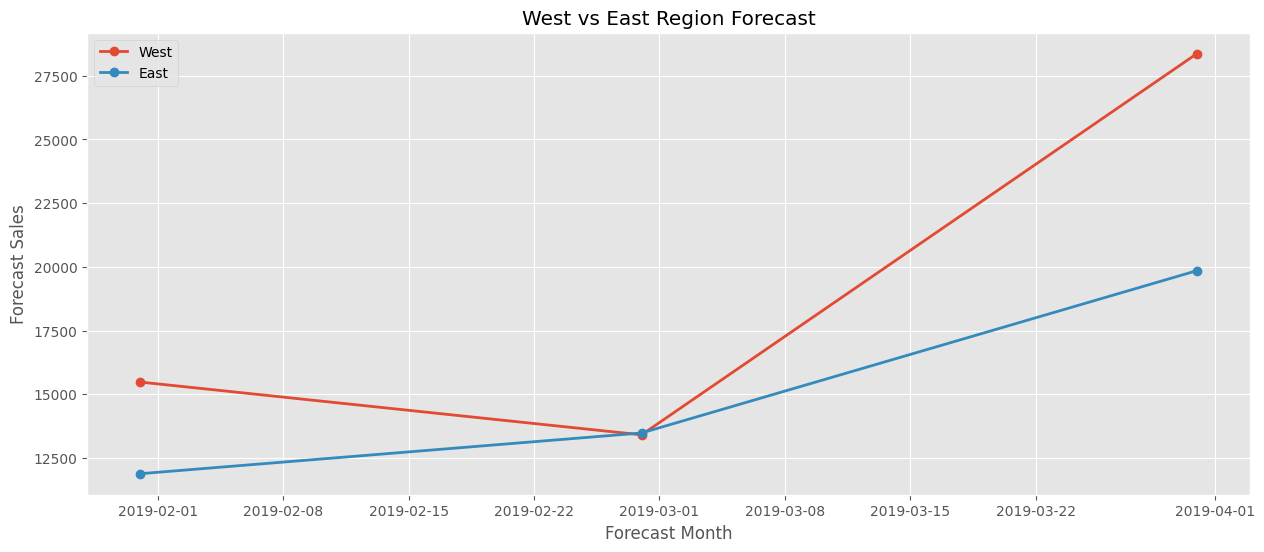

In [40]:
plt.figure(figsize=(15,6))

plt.plot(
    region_comparison.index,
    region_comparison["West"],
    marker="o",
    linewidth=2,
    label="West"
)

plt.plot(
    region_comparison.index,
    region_comparison["East"],
    marker="o",
    linewidth=2,
    label="East"
)

plt.title("West vs East Region Forecast")

plt.xlabel("Forecast Month")

plt.ylabel("Forecast Sales")

plt.legend()

plt.grid(True)

plt.show()

# Growth Summary

In [41]:
growth_summary = pd.DataFrame({

    "Region": ["West", "East"],

    "Average Forecast Sales": [

        west_prediction.mean(),

        east_prediction.mean()

    ]

})

growth_summary = growth_summary.sort_values(
    by="Average Forecast Sales",
    ascending=False
)

growth_summary

,Region,Average Forecast Sales
0,West,19083.13145
1,East,15068.25077


In [42]:
west_forecast.to_csv(
    "west_region_forecast.csv"
)

east_forecast.to_csv(
    "east_region_forecast.csv"
)

region_comparison.to_csv(
    "region_forecast_comparison.csv"
)

growth_summary.to_csv(
    "region_growth_summary.csv",
    index=False
)

print("Region forecast files saved successfully.")

Region forecast files saved successfully.


# combined Forecast

In [43]:
# ==========================================
# Combine Category & Region Forecasts
# ==========================================

combined_forecast = pd.DataFrame({

    "Furniture": furniture_prediction.values,

    "Technology": technology_prediction.values,

    "Office Supplies": office_prediction.values,

    "West": west_prediction.values,

    "East": east_prediction.values

},
index=furniture_prediction.index)

combined_forecast.index.name = "Forecast Date"

combined_forecast

,Furniture,Technology,Office Supplies,West,East
Forecast Date,,,,,
2019-01-31,10526.766773,20100.376895,17978.323410,15478.135160,11878.473034
2019-02-28,9921.588935,18198.549188,15467.386741,13405.168156,13477.979195
2019-03-31,16576.869442,32443.115061,23346.412014,28366.091033,19848.300081


# 3 Month Forecast Comparison

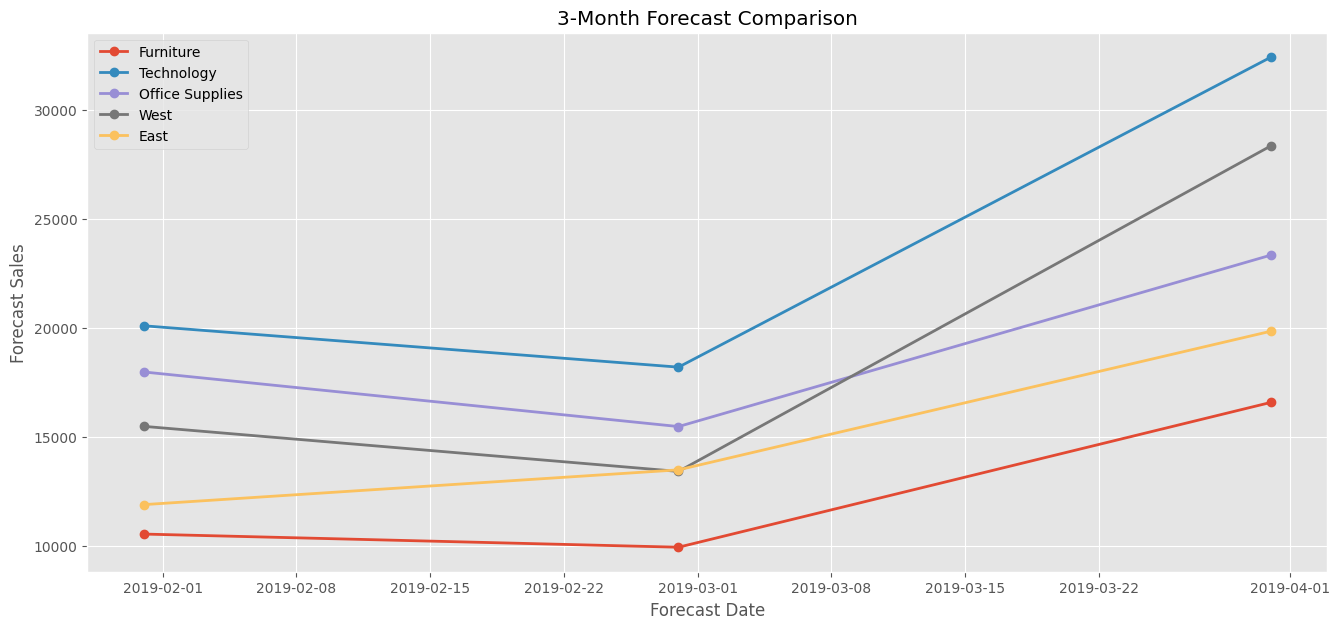

In [45]:
plt.figure(figsize=(16,7))

for column in combined_forecast.columns:

    plt.plot(
        combined_forecast.index,
        combined_forecast[column],
        marker="o",
        linewidth=2,
        label=column
    )

plt.title("3-Month Forecast Comparison")

plt.xlabel("Forecast Date")

plt.ylabel("Forecast Sales")

plt.legend()

plt.grid(True)

plt.show()

# Average Forecast

In [46]:
average_forecast = pd.DataFrame({

    "Segment": combined_forecast.columns,

    "Average Forecast Sales": combined_forecast.mean().values

})

average_forecast

,Segment,Average Forecast Sales
0,Furniture,12341.741716
1,Technology,23580.680381
2,Office Supplies,18930.707388
3,West,19083.131450
4,East,15068.250770


In [47]:
average_forecast = average_forecast.sort_values(
    by="Average Forecast Sales",
    ascending=False
)

average_forecast.reset_index(drop=True, inplace=True)

average_forecast

,Segment,Average Forecast Sales
0,Technology,23580.680381
1,West,19083.131450
2,Office Supplies,18930.707388
3,East,15068.250770
4,Furniture,12341.741716


In [48]:
best_segment = average_forecast.iloc[0]

print("Highest Growth Segment")

print("----------------------")

print(best_segment)

Highest Growth Segment
----------------------
Segment                     Technology
Average Forecast Sales    23580.680381
Name: 0, dtype: object


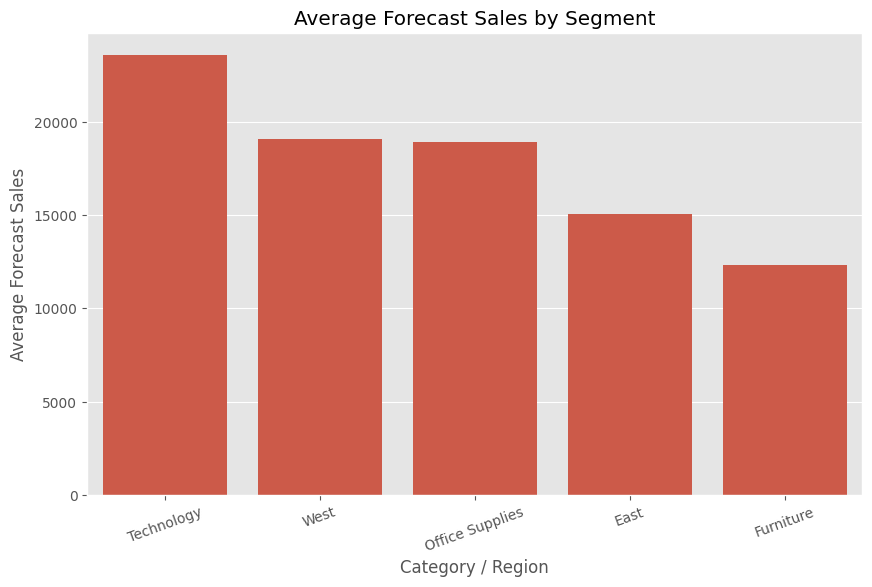

In [49]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=average_forecast,
    x="Segment",
    y="Average Forecast Sales"
)

plt.title("Average Forecast Sales by Segment")

plt.xlabel("Category / Region")

plt.ylabel("Average Forecast Sales")

plt.xticks(rotation=20)

plt.show()

In [50]:
business_summary = pd.DataFrame({

    "Forecast Segment": average_forecast["Segment"],

    "Expected Demand":

    np.where(

        average_forecast["Average Forecast Sales"] >

        average_forecast["Average Forecast Sales"].mean(),

        "High",

        "Moderate"

    )

})

business_summary

,Forecast Segment,Expected Demand
0,Technology,High
1,West,High
2,Office Supplies,High
3,East,Moderate
4,Furniture,Moderate


In [51]:
combined_forecast.to_csv(
    "combined_forecast.csv"
)

average_forecast.to_csv(
    "forecast_ranking.csv",
    index=False
)

business_summary.to_csv(
    "business_summary.csv",
    index=False
)

print("Final comparison results saved successfully.")

Final comparison results saved successfully.
